# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('All libraries imported successfully.')

All libraries imported successfully.


### 1. Data Preparation

In [3]:
# Load Boston Housing from OpenML (identical to the original sklearn dataset)
boston = fetch_openml(name='boston', version=1, as_frame=True)

X = boston.data.astype(float)
y = boston.target.astype(float)

print('Dataset shape:', X.shape)
print('Target shape :', y.shape)
print('\nFeature names:')
print(list(X.columns))

Dataset shape: (506, 13)
Target shape : (506,)

Feature names:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [ ]:
df = X.copy()
df['MEDV'] = y
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [5]:
# Basic statistics
df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [6]:
# Check for missing values
print('Missing values per column:')
print(X.isnull().sum())
print('\nNo missing values —', 'ready to split.' if X.isnull().sum().sum() == 0 else 'handle them first.')

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64

No missing values — ready to split.


In [7]:
# Train / Test split  (80% train, 20% test, reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 404
Test samples     : 102


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [8]:
# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

print('Linear Regression trained.')

Linear Regression trained.


In [9]:
# Evaluation metrics
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_mse  = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)

print('=== Linear Regression — Test Metrics ===')
print(f'  MAE  : {lr_mae:.4f}')
print(f'  MSE  : {lr_mse:.4f}')
print(f'  RMSE : {lr_rmse:.4f}')

=== Linear Regression — Test Metrics ===
  MAE  : 3.1891
  MSE  : 24.2911
  RMSE : 4.9286


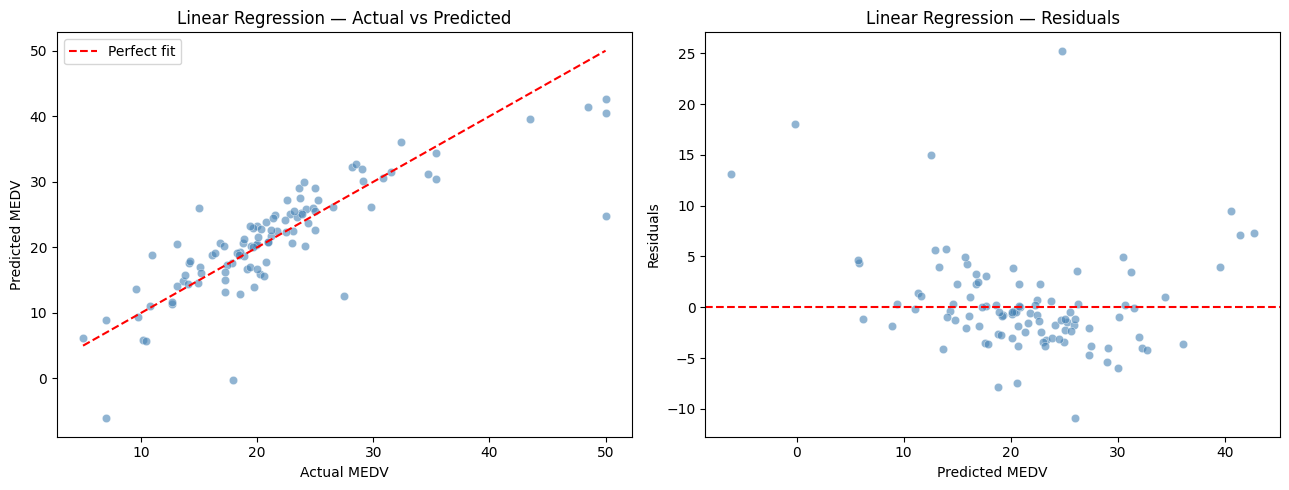

In [10]:
# Actual vs Predicted plot — Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.4)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual MEDV')
axes[0].set_ylabel('Predicted MEDV')
axes[0].set_title('Linear Regression — Actual vs Predicted')
axes[0].legend()

# Residuals
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.4)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted MEDV')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Linear Regression — Residuals')

plt.tight_layout()
plt.show()

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [11]:
# We use a Pipeline: StandardScaler → PolynomialFeatures(degree=2) → LinearRegression
# Scaling is important before polynomial expansion to avoid numerical instability.

poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',     LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

# How many features after expansion?
n_features_poly = poly_pipeline.named_steps['poly'].n_output_features_
print(f'Original features     : {X_train.shape[1]}')
print(f'After degree-2 expand : {n_features_poly}')
print('Polynomial Regression trained.')

Original features     : 13
After degree-2 expand : 104
Polynomial Regression trained.


In [12]:
# Predict
y_pred_poly = poly_pipeline.predict(X_test)

# Evaluation metrics
poly_mae  = mean_absolute_error(y_test, y_pred_poly)
poly_mse  = mean_squared_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(poly_mse)

print('=== Polynomial Regression (degree=2) — Test Metrics ===')
print(f'  MAE  : {poly_mae:.4f}')
print(f'  MSE  : {poly_mse:.4f}')
print(f'  RMSE : {poly_rmse:.4f}')

=== Polynomial Regression (degree=2) — Test Metrics ===
  MAE  : 2.5744
  MSE  : 14.2552
  RMSE : 3.7756


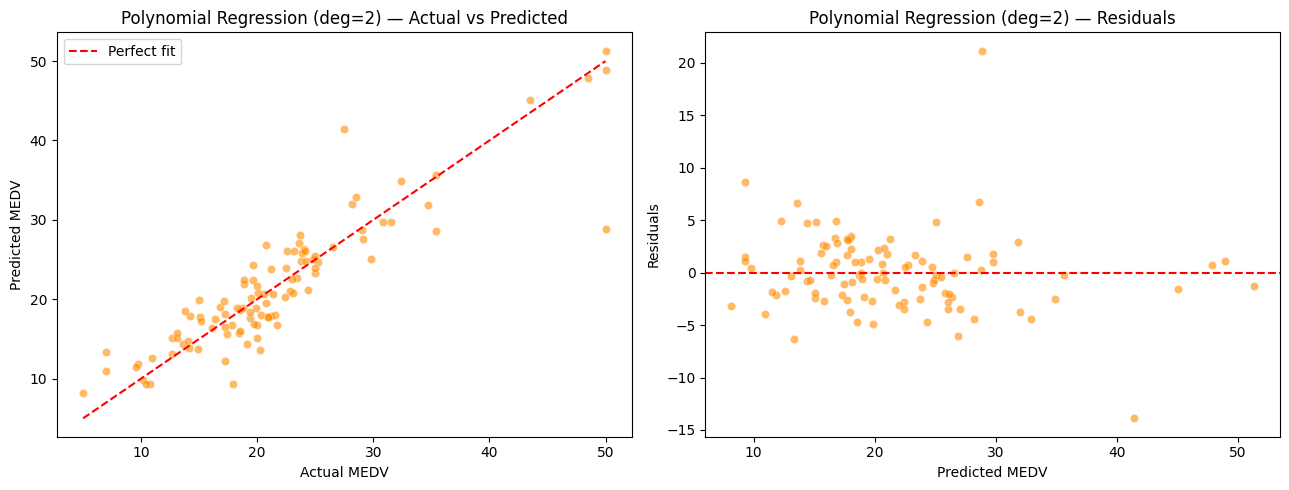

In [13]:
# Actual vs Predicted plot — Polynomial Regression
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_poly, alpha=0.6, color='darkorange', edgecolors='white', linewidths=0.4)
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual MEDV')
axes[0].set_ylabel('Predicted MEDV')
axes[0].set_title('Polynomial Regression (deg=2) — Actual vs Predicted')
axes[0].legend()

residuals_poly = y_test - y_pred_poly
axes[1].scatter(y_pred_poly, residuals_poly, alpha=0.6, color='darkorange', edgecolors='white', linewidths=0.4)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted MEDV')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Polynomial Regression (deg=2) — Residuals')

plt.tight_layout()
plt.show()

### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


In [17]:
# Summary table
comparison = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Polynomial Regression (deg=2)'],
    'MAE'    : [round(lr_mae,  4), round(poly_mae,  4)],
    'MSE'    : [round(lr_mse,  4), round(poly_mse,  4)],
    'RMSE'   : [round(lr_rmse, 4), round(poly_rmse, 4)],
})

comparison.set_index('Model', inplace=True)

# Highlight the lower (better) value in each column
comparison.style.highlight_min( axis=0)

,MAE,MSE,RMSE
Model,,,
Linear Regression,3.189100,24.291100,4.928600
Polynomial Regression (deg=2),2.574400,14.255200,3.775600


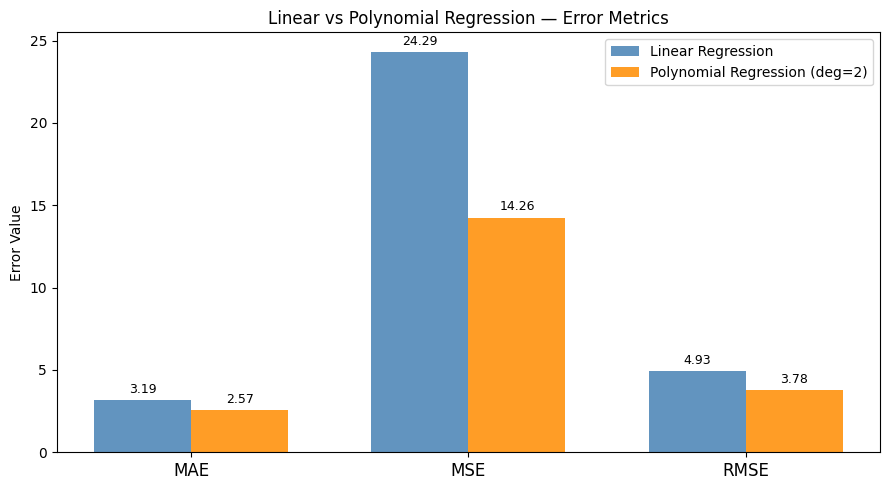

In [18]:
# Bar chart comparison
metrics = ['MAE', 'MSE', 'RMSE']
lr_scores   = [lr_mae,   lr_mse,   lr_rmse]
poly_scores = [poly_mae, poly_mse, poly_rmse]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores,   width, label='Linear Regression',             color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, poly_scores, width, label='Polynomial Regression (deg=2)', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Error Value')
ax.set_title('Linear vs Polynomial Regression — Error Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

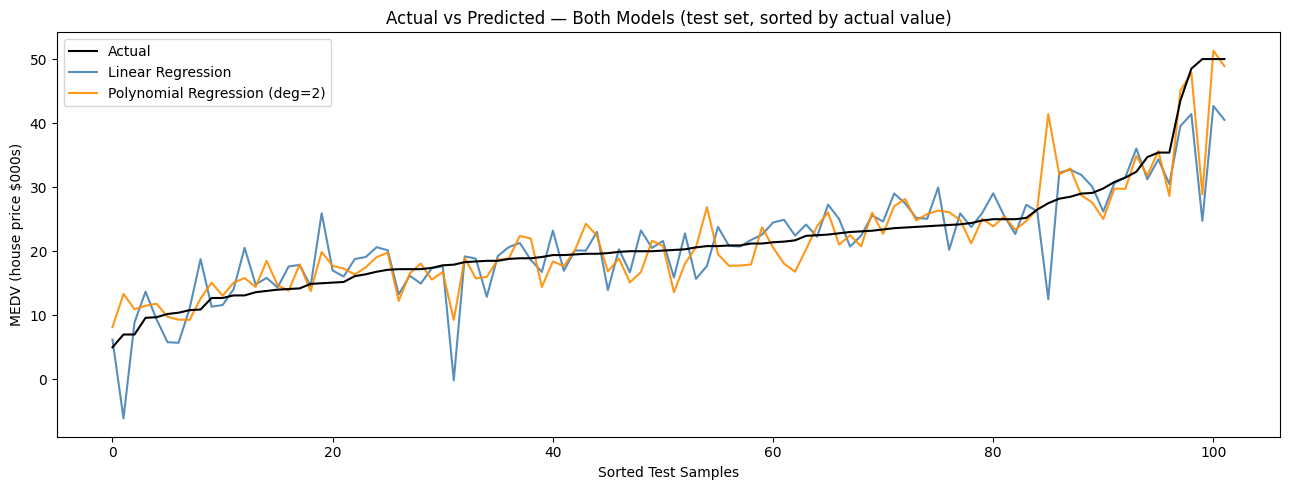

In [19]:
# Overlay predictions on the same plot for visual comparison
sort_idx  = np.argsort(y_test.values)
y_actual  = y_test.values[sort_idx]
y_lr_s    = y_pred_lr[sort_idx]
y_poly_s  = y_pred_poly[sort_idx]

plt.figure(figsize=(13, 5))
plt.plot(y_actual,  label='Actual',                       color='black',      lw=1.5, zorder=3)
plt.plot(y_lr_s,    label='Linear Regression',            color='steelblue',  lw=1.5, alpha=0.9)
plt.plot(y_poly_s,  label='Polynomial Regression (deg=2)',color='darkorange', lw=1.5, alpha=0.9)
plt.xlabel('Sorted Test Samples')
plt.ylabel('MEDV (house price $000s)')
plt.title('Actual vs Predicted — Both Models (test set, sorted by actual value)')
plt.legend()
plt.tight_layout()
plt.show()

### Best Model: Polynomial Regression (degree=2)
Why it wins:

RMSE dropped from 4.93 → 3.78 (a ~23% improvement) — meaning on average predictions are off by $3,780 instead of $4,930

MSE nearly halved (24.29 → 14.26), which means large prediction errors were significantly reduced

Linear regression assumes a straight-line relationship between every feature and price — but real housing data doesn't work that way